# DecodeLabs Project 2
# Exploratory Data Analysis (EDA)

In [2]:
# Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


# Load Dataset

In [3]:
df = pd.read_excel("Dataset for Data Analytics 2.xlsx")

print("\nDataset Loaded Successfully")


Dataset Loaded Successfully


# Basic Information

In [4]:
print("\nShape:")
print(df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nFirst 5 Rows:")
print(df.head())


Shape:
(1200, 14)

Columns:
['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice', 'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber', 'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice']

Data Types:
OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object

First 5 Rows:
     OrderID       Date CustomerID  Product  Quantity  UnitPrice  \
0  ORD200000 2023-01-04     C72649  Monitor         5     570.62   
1  ORD200001 2024-08-23     C75739    Phone         2     151.35   
2  ORD200002 2024-02-27     C81728   Tablet      

# Missing Values

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64


# Statistical Summary

In [6]:
print("\nStatistical Summary")

print(df.describe())


Statistical Summary
                      Date     Quantity    UnitPrice  ItemsInCart   TotalPrice
count                 1200  1200.000000  1200.000000  1200.000000  1200.000000
mean   2024-03-22 16:58:48     2.945833   356.412750     5.485000  1053.968300
min    2023-01-01 00:00:00     1.000000    11.390000     1.000000    11.390000
25%    2023-08-03 18:00:00     2.000000   186.062500     4.000000   410.520000
50%    2024-03-23 00:00:00     3.000000   364.210000     5.000000   823.615000
75%    2024-11-08 12:00:00     4.000000   521.570000     7.000000  1578.475000
max    2025-06-30 00:00:00     5.000000   699.930000    10.000000  3456.400000
std                    NaN     1.407557   197.177146     2.281983   819.856558


# Mean Median Mode

In [7]:
numeric_cols = [
    'Quantity',
    'UnitPrice',
    'ItemsInCart',
    'TotalPrice'
]

for col in numeric_cols:

    print("\n===================")
    print(col)
    print("===================")

    print("Mean :", df[col].mean())
    print("Median :", df[col].median())
    print("Mode :", df[col].mode()[0])


Quantity
Mean : 2.9458333333333333
Median : 3.0
Mode : 1

UnitPrice
Mean : 356.41275
Median : 364.21
Mode : 127.18

ItemsInCart
Mean : 5.485
Median : 5.0
Mode : 5

TotalPrice
Mean : 1053.9683
Median : 823.615
Mode : 211.14


# Product Analysis


Products Sold:
Product
Printer    181
Tablet     179
Chair      178
Laptop     173
Desk       170
Monitor    163
Phone      156
Name: count, dtype: int64


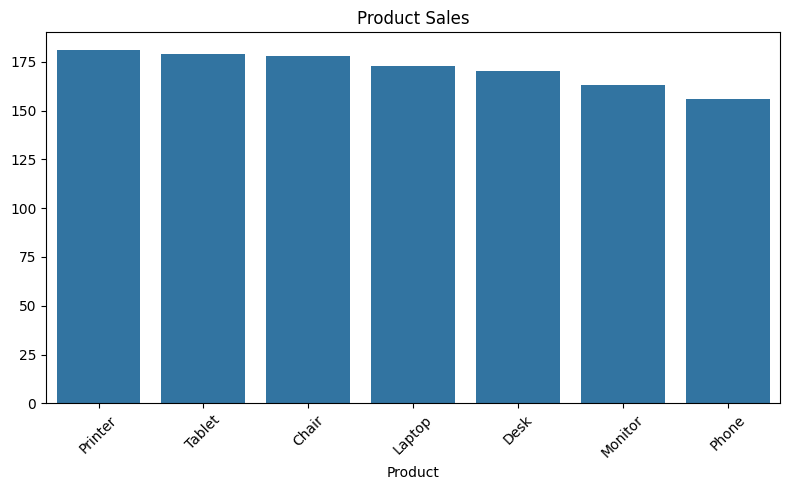

In [8]:
product_counts = df["Product"].value_counts()

print("\nProducts Sold:")
print(product_counts)

plt.figure(figsize=(8,5))
sns.barplot(
    x=product_counts.index,
    y=product_counts.values
)

plt.title("Product Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("product_sales.png")

plt.show()


# Payment Method Analysis

PaymentMethod
Online         258
Cash           246
Credit Card    234
Debit Card     232
Gift Card      230
Name: count, dtype: int64


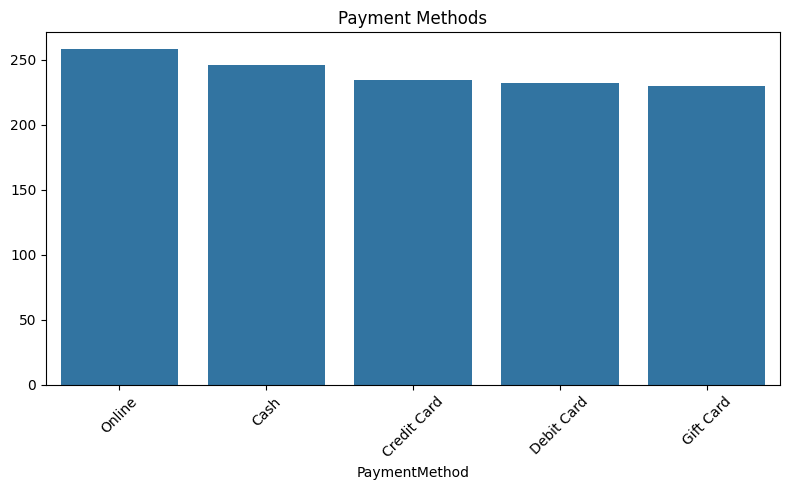

In [9]:
payment_counts = df["PaymentMethod"].value_counts()

print(payment_counts)

plt.figure(figsize=(8,5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Payment Methods")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig("payment_methods.png")

plt.show()

# Referral Source Analysis

In [10]:
print("\nReferral Sources")

print(
    df["ReferralSource"].value_counts()
)


Referral Sources
ReferralSource
Instagram    259
Email        250
Google       241
Facebook     228
Referral     222
Name: count, dtype: int64


# Order Status Analysis

In [11]:
print("\nOrder Status")

print(
    df["OrderStatus"].value_counts()
)


Order Status
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64


# Distribution Analysis

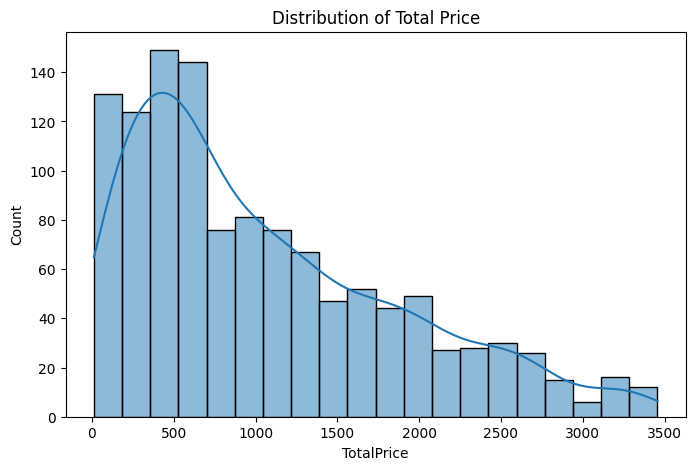

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(
    df["TotalPrice"],
    bins=20,
    kde=True
)

plt.title("Distribution of Total Price")

plt.savefig("totalprice_histogram.png")

plt.show()

# Outlier Detection

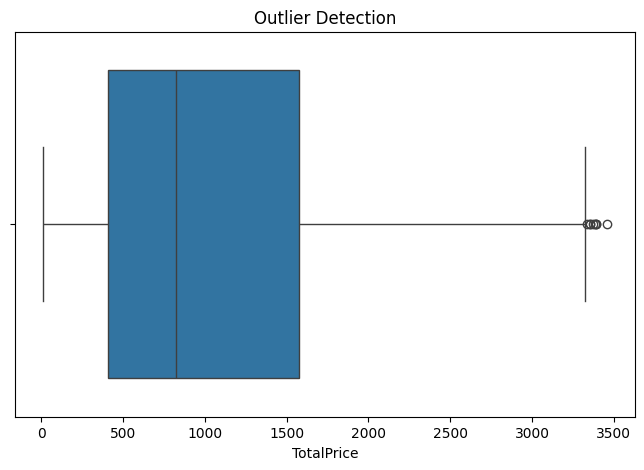

In [13]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df["TotalPrice"]
)

plt.title("Outlier Detection")

plt.savefig("totalprice_boxplot.png")

plt.show()

# IQR Outliers

In [14]:
Q1 = df["TotalPrice"].quantile(0.25)

Q3 = df["TotalPrice"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["TotalPrice"] < lower_bound)
    |
    (df["TotalPrice"] > upper_bound)
]

print("\nNumber of Outliers:")

print(len(outliers))


Number of Outliers:
8


# Correlation Analysis


Correlation Matrix
             Quantity  UnitPrice  ItemsInCart  TotalPrice
Quantity     1.000000   0.014553     0.650061    0.615251
UnitPrice    0.014553   1.000000     0.000602    0.717081
ItemsInCart  0.650061   0.000602     1.000000    0.392540
TotalPrice   0.615251   0.717081     0.392540    1.000000


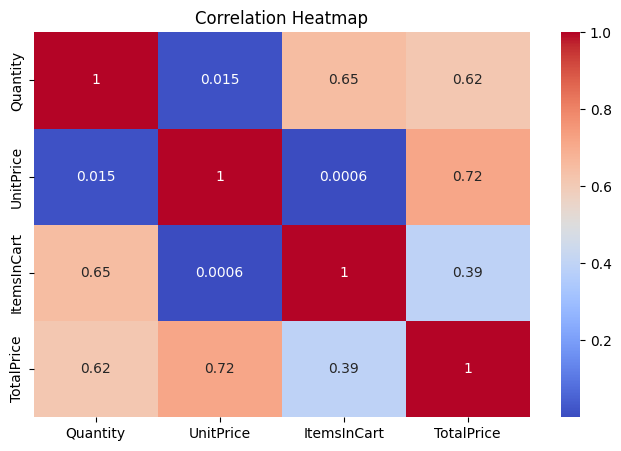

In [15]:
corr = df[
    [
        "Quantity",
        "UnitPrice",
        "ItemsInCart",
        "TotalPrice"
    ]
].corr()

print("\nCorrelation Matrix")

print(corr)

plt.figure(figsize=(8,5))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("correlation_heatmap.png")

plt.show()

# Top 10 Expensive Orders

In [16]:
print("\nTop 10 Orders")

print(
    df.nlargest(
        10,
        "TotalPrice"
    )[
        [
            "OrderID",
            "Product",
            "TotalPrice"
        ]
    ]
)


Top 10 Orders
        OrderID  Product  TotalPrice
789   ORD200789   Tablet     3456.40
1122  ORD201122  Monitor     3390.95
632   ORD200632   Laptop     3390.80
469   ORD200469    Chair     3384.90
328   ORD200328   Tablet     3370.20
107   ORD200107  Printer     3353.75
326   ORD200326   Laptop     3352.40
1065  ORD201065  Printer     3334.00
1031  ORD201031    Phone     3322.55
463   ORD200463   Laptop     3313.90


# Final Summary

In [17]:
print("\n========== EDA COMPLETE ==========")

print("Rows:", df.shape[0])

print("Columns:", df.shape[1])

print(
    "Average Total Price:",
    round(df["TotalPrice"].mean(),2)
)

print(
    "Median Total Price:",
    round(df["TotalPrice"].median(),2)
)

print(
    "Maximum Total Price:",
    round(df["TotalPrice"].max(),2)
)

print(
    "Minimum Total Price:",
    round(df["TotalPrice"].min(),2)
)

print("\nProject 2 Completed Successfully")


========== EDA COMPLETE ==========
Rows: 1200
Columns: 14
Average Total Price: 1053.97
Median Total Price: 823.62
Maximum Total Price: 3456.4
Minimum Total Price: 11.39

Project 2 Completed Successfully
